In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse.linalg import LinearOperator, eigsh
from torch.utils.data import DataLoader
from scripts.utils import create_synthetic_dataset, FlatMLP, train_model
print("--- Original Exp 1: Temporal Genesis of Alignment ---")

--- Original Exp 1: Temporal Genesis of Alignment ---


In [5]:
dataset = create_synthetic_dataset()
input_dim = dataset.tensors[0].shape[1]
criterion = torch.nn.CrossEntropyLoss()
model = FlatMLP(input_dim=input_dim, hidden_dim=512, num_classes=10)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)
full_dataloader = torch.utils.data.DataLoader(dataset, batch_size=len(dataset), shuffle=False)

In [6]:
import torch
from scripts.utils import create_synthetic_dataset, FlatMLP, train_model


print("Phase 1: The Burn-in (Equilibration)...")
print("Training the model to reach the bottom of the minimum (theta*).")

# 3. Train the model to eliminate macroscopic drift
# We want it to thoroughly settle into the minimum, so 200-300 epochs is safe.
trained_model = train_model(
    dataset=dataset, 
    input_dim=input_dim,
    lr=0.005, 
    batch_size=64, 
    epochs=250
)

# 4. Freeze the state
# We will use this trained_model for Phase 2 and 3
trained_model.eval()
print("Equilibration complete! The model is now resting at theta*.")

Phase 1: The Burn-in (Equilibration)...
Training the model to reach the bottom of the minimum (theta*).
Epoch [100/250] | Loss: 0.0001 | Temp (lr/B): 0.00008
Epoch [200/250] | Loss: 0.0000 | Temp (lr/B): 0.00008
Equilibration complete! The model is now resting at theta*.


Phase 1: The Burn-in (Equilibration)...
Training the model to reach the bottom of the minimum (theta*).
Epoch [100/250] | Loss: 0.0001 | Temp (lr/B): 0.00008
Epoch [200/250] | Loss: 0.0000 | Temp (lr/B): 0.00008
Equilibration complete! The model is now resting at theta*.
--- Phase 3: Microscopic Alignment (Sigma vs Hessian) ---
1. Sampling gradient noise...
2. Computing Top Principal Components of the Noise (Sigma)...
3. Computing Top Eigenvectors of the Hessian (H)...
4. Calculating Subspace Overlap...
Plotting the Alignment Heatmap...


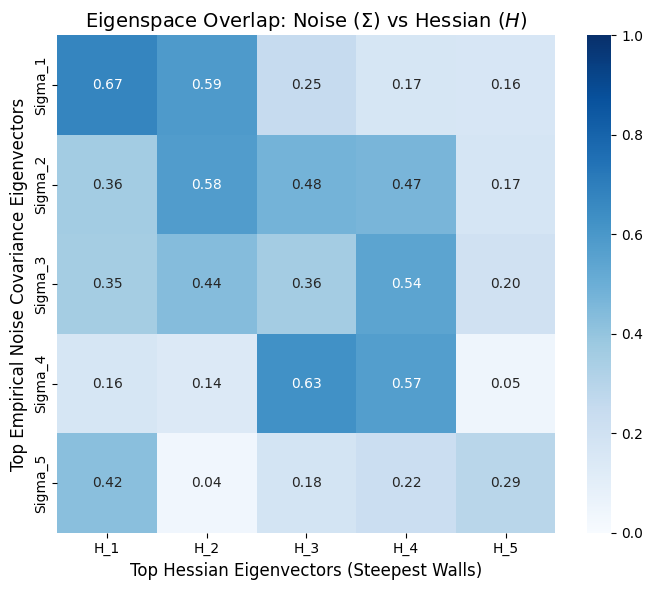

In [7]:
import torch
from scripts.utils import create_synthetic_dataset, FlatMLP, train_model

dataset = create_synthetic_dataset()
input_dim = dataset.tensors[0].shape[1]  # Should be 100
model = FlatMLP(input_dim=input_dim, hidden_dim=512, num_classes=10)

print("Phase 1: The Burn-in (Equilibration)...")
print("Training the model to reach the bottom of the minimum (theta*).")

# 3. Train the model to eliminate macroscopic drift
# We want it to thoroughly settle into the minimum, so 200-300 epochs is safe.
trained_model = train_model(
    dataset=dataset, 
    input_dim=input_dim,
    lr=0.005, 
    batch_size=64, 
    epochs=250
)

# 4. Freeze the state
# We will use this trained_model for Phase 2 and 3
trained_model.eval()
print("Equilibration complete! The model is now resting at theta*.")
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse.linalg import LinearOperator, eigsh
from torch.utils.data import DataLoader

# --- Settings ---
K = 5  # Number of top dimensions to compare
B = 64 # Mini-batch size for the noise
num_noise_samples = 500

print(f"--- Phase 3: Microscopic Alignment (Sigma vs Hessian) ---")
print("1. Sampling gradient noise...")

trained_model.eval()
criterion = torch.nn.CrossEntropyLoss()
device = next(trained_model.parameters()).device

# Function to get flattened gradient
def get_flat_gradient(X_batch, y_batch):
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    trained_model.zero_grad()
    loss = criterion(trained_model(X_batch), y_batch)
    loss.backward()
    grads = [p.grad.contiguous().view(-1) for p in trained_model.parameters() if p.grad is not None]
    return torch.cat(grads)

# Get True Gradient (Full Batch)
# Note: For N=10000 you can load it in one batch, or accumulate it. 
# We'll assume full_dataloader can yield the whole dataset for the true gradient.
X_full, y_full = next(iter(full_dataloader))
true_grad = get_flat_gradient(X_full, y_full).detach().cpu().numpy()

# Sample mini-batch noise
mini_loader = DataLoader(dataset, batch_size=B, shuffle=True)
loader_iter = iter(mini_loader)

noise_matrix = []
for _ in range(num_noise_samples):
    try:
        X, y = next(loader_iter)
    except StopIteration:
        loader_iter = iter(mini_loader)
        X, y = next(loader_iter)
    
    if len(X) != B: continue
    
    mini_grad = get_flat_gradient(X, y).detach().cpu().numpy()
    noise_vector = mini_grad - true_grad
    noise_matrix.append(noise_vector)

noise_matrix = np.array(noise_matrix) # Shape: (500, M)
noise_mean = noise_matrix.mean(axis=0, keepdims=True)
centered_noise_matrix = noise_matrix - noise_mean

print("2. Computing Top Principal Components of the Noise (Sigma)...")
# SVD on centered samples extracts the eigendirections of the empirical covariance
U, S, Vh = np.linalg.svd(centered_noise_matrix, full_matrices=False)
noise_eigenvectors = Vh[:K] # Top K directions of the noise

print("3. Computing Top Eigenvectors of the Hessian (H)...")
# We use Hessian-Vector Products to avoid memory explosion

def compute_hvp(v_np):
    """Calculates H * v exactly without forming H."""
    v_tensor = torch.tensor(v_np, dtype=torch.float32).to(device)
    hvp_accum = torch.zeros_like(v_tensor)
    
    # We accumulate over batches to save GPU/CPU memory
    for X_b, y_b in DataLoader(dataset, batch_size=500):
        X_b, y_b = X_b.to(device), y_b.to(device)
        trained_model.zero_grad()
        loss = criterion(trained_model(X_b), y_b)
        
        # 1st derivative
        grads = torch.autograd.grad(loss, trained_model.parameters(), create_graph=True)
        flat_grad = torch.cat([g.contiguous().view(-1) for g in grads])
        
        # Dot product with vector v
        grad_v = torch.dot(flat_grad, v_tensor)
        
        # 2nd derivative (Hessian-vector product)
        hvp_grads = torch.autograd.grad(grad_v, trained_model.parameters())
        flat_hvp = torch.cat([g.contiguous().view(-1) for g in hvp_grads])
        
        hvp_accum += flat_hvp * len(X_b)
        
    return (hvp_accum / len(dataset)).detach().cpu().numpy()

# Define the matrix-free Linear Operator for SciPy
M = sum(p.numel() for p in trained_model.parameters())
H_op = LinearOperator((M, M), matvec=compute_hvp)

# scipy.sparse.linalg.eigsh finds the top K eigenvalues/eigenvectors using Lanczos iteration
evals, evecs = eigsh(H_op, k=K, which='LA')
# evecs are returned in ascending order, so we reverse them
hessian_eigenvectors = evecs[:, ::-1].T # Shape: (K, M)

print("4. Calculating Subspace Overlap...")
# We take the absolute dot product (cosine similarity) between the two sets of vectors
overlap_matrix = np.abs(np.dot(noise_eigenvectors, hessian_eigenvectors.T))

print("Plotting the Alignment Heatmap...")
fig, ax = plt.subplots(figsize=(7, 6))

sns.heatmap(overlap_matrix, annot=True, cmap='Blues', fmt=".2f", 
            xticklabels=[f"H_{i+1}" for i in range(K)], 
            yticklabels=[f"Sigma_{i+1}" for i in range(K)], 
            vmin=0, vmax=1, ax=ax)

ax.set_title("Eigenspace Overlap: Noise ($\Sigma$) vs Hessian ($H$)", fontsize=14)
ax.set_xlabel("Top Hessian Eigenvectors (Steepest Walls)", fontsize=12)
ax.set_ylabel("Top Empirical Noise Covariance Eigenvectors", fontsize=12)

plt.tight_layout()
plt.savefig("Hessian_Noise_Alignment.png", dpi=300)
plt.show()


Alignment evolution: Noise covariance Σ vs Hessian H eigenspace
  K = 5,  lr = 0.005,  B = 64,  total_steps = 30
  Alignment snapshots at steps: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
  Loss recorded every 500 steps
  Noise sampling seed fixed at 0 across all snapshots

  Model dimension M = 56842
  Random-subspace baseline = 8.80e-05

  Step      0  loss = 3.3469  avg cos²θ = 0.17177  (4.2s)
  Step      1  loss = 1.7894  avg cos²θ = 0.24873  (3.3s)
  Step      2  loss = 1.0453  avg cos²θ = 0.41356  (4.1s)
  Step      3  loss = 0.5819  avg cos²θ = 0.53545  (4.1s)
  Step      4  loss = 0.3938  avg cos²θ = 0.68983  (4.2s)
  Step      5  loss = 0.2499  avg cos²θ = 0.73300  (3.3s)
  Step      6  loss = 0.1944  avg cos²θ = 0.90355  (3.3s)
  Step      7  loss = 0.1545  avg cos²θ = 0.81771  (3.0s)
  Step      8  loss = 0.1287  avg cos²θ = 0.77854  (3.2s)
  Step      9  loss = 0.1098  avg cos²θ = 0.71913  (3.1s)
  Step    

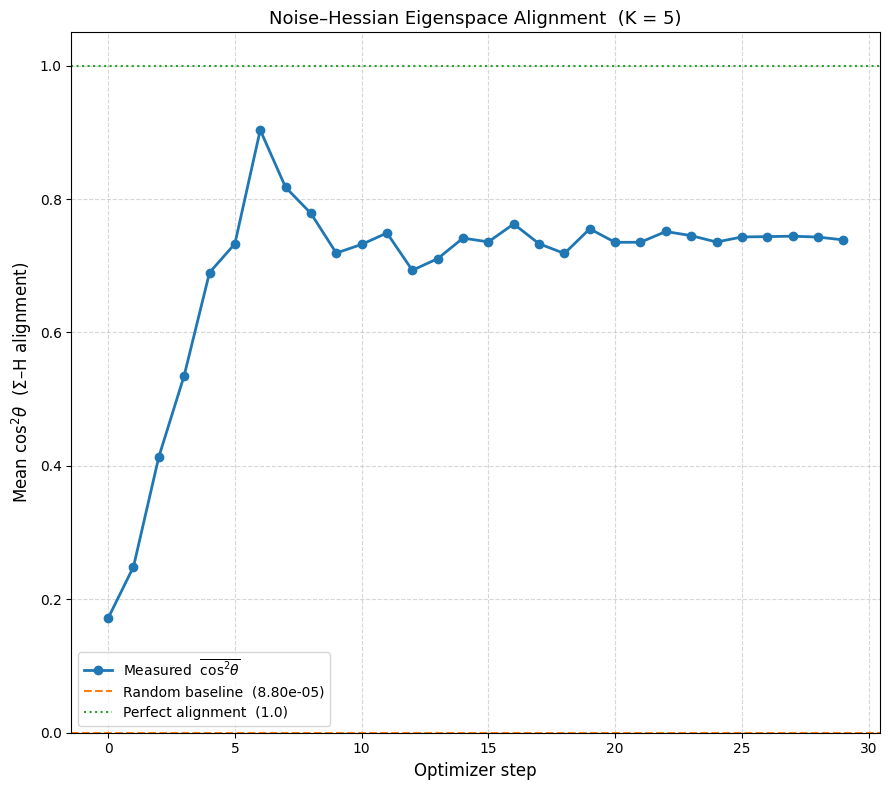

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.sparse.linalg import LinearOperator, eigsh
from torch.utils.data import DataLoader
from scripts.utils import FlatMLP

# ── Settings ───────────────────────────────────────────────────────────────────
K_align        = 5       # subspace dimension (same as heatmap)
B_noise        = 64      # batch size for noise sampling
num_noise      = 150     # noise samples per snapshot
lr_train       = 0.005
B_train        = 64
total_steps    = 30      # optimizer steps (consistent with sweep cells)
steps_per_loss = 500     # full-batch loss evaluation interval
SEED           = 42
NOISE_SEED     = 0       # fixed seed for mini-batch draws in every snapshot
                         # → same batches used at every snapshot, removing
                         #   sampling variance from the alignment signal

# Alignment snapshots: dense early, coarser later (logarithmic-ish spacing)
snapshot_steps = sorted(set(range(0, 30, 1)))
snapshot_set   = set(snapshot_steps)

print(f"Alignment evolution: Noise covariance Σ vs Hessian H eigenspace")
print(f"  K = {K_align},  lr = {lr_train},  B = {B_train},  total_steps = {total_steps}")
print(f"  Alignment snapshots at steps: {snapshot_steps}")
print(f"  Loss recorded every {steps_per_loss} steps")
print(f"  Noise sampling seed fixed at {NOISE_SEED} across all snapshots")

# ── Helper: top-K noise covariance eigenvectors ────────────────────────────────
def get_noise_eigenvectors(model, dataset, B, num_samples, K, device, seed=0):
    """
    SVD on centered noise samples → top-K directions of Σ.
    `seed` pins the DataLoader shuffle so the same mini-batches are drawn
    at every snapshot, removing sampling randomness from the alignment signal.
    """
    crit = torch.nn.CrossEntropyLoss()
    X_f, y_f = dataset.tensors[0].to(device), dataset.tensors[1].to(device)
    model.zero_grad()
    crit(model(X_f), y_f).backward()
    true_g = torch.cat([p.grad.contiguous().view(-1) for p in model.parameters()
                        if p.grad is not None]).detach().cpu().numpy()

    g_noise = torch.Generator()
    g_noise.manual_seed(seed)
    loader = DataLoader(dataset, batch_size=B, shuffle=True, generator=g_noise)
    it = iter(loader)
    samples = []
    while len(samples) < num_samples:
        try:
            Xb, yb = next(it)
        except StopIteration:
            # Re-seed so we cycle through the same permutation order again
            g_noise.manual_seed(seed)
            it = iter(DataLoader(dataset, batch_size=B, shuffle=True, generator=g_noise))
            Xb, yb = next(it)
        if len(Xb) != B:
            continue
        model.zero_grad()
        Xb, yb = Xb.to(device), yb.to(device)
        crit(model(Xb), yb).backward()
        mini_g = torch.cat([p.grad.contiguous().view(-1) for p in model.parameters()
                            if p.grad is not None]).detach().cpu().numpy()
        samples.append(mini_g - true_g)

    noise_mat = np.array(samples)
    noise_mat -= noise_mat.mean(axis=0, keepdims=True)
    _, _, Vh = np.linalg.svd(noise_mat, full_matrices=False)
    return Vh[:K]   # (K, M)

# ── Helper: top-K Hessian eigenvectors ────────────────────────────────────────
def get_hessian_eigenvectors(model, dataset, K, device):
    crit = torch.nn.CrossEntropyLoss()
    M_dim = sum(p.numel() for p in model.parameters())

    def hvp(v_np):
        v_t = torch.tensor(v_np, dtype=torch.float32, device=device)
        accum = torch.zeros_like(v_t)
        for Xb, yb in DataLoader(dataset, batch_size=512, shuffle=False):
            Xb, yb = Xb.to(device), yb.to(device)
            model.zero_grad()
            loss = crit(model(Xb), yb)
            grads = torch.autograd.grad(loss, model.parameters(), create_graph=True)
            gv = torch.dot(torch.cat([g.contiguous().view(-1) for g in grads]), v_t)
            hg = torch.autograd.grad(gv, model.parameters())
            accum += torch.cat([g.contiguous().view(-1) for g in hg]) * len(Xb)
        return (accum / len(dataset)).detach().cpu().numpy()

    H_op = LinearOperator((M_dim, M_dim), matvec=hvp)
    _, evecs_snap = eigsh(H_op, k=K, which='LA', tol=1e-3)
    return evecs_snap[:, ::-1].T   # (K, M)

# ── Helper: average cos²(θ) between two K-dim subspaces ───────────────────────
def mean_cos2_theta(Q_a, Q_b):
    G  = Q_a @ Q_b.T
    sv = np.linalg.svd(G, compute_uv=False)
    return float(np.mean(sv ** 2))

# ── Full-batch loss evaluation ─────────────────────────────────────────────────
def full_batch_loss(model, dataset, device, batch_size=512):
    crit = torch.nn.CrossEntropyLoss()
    total_loss, total_n = 0.0, 0
    model.eval()
    with torch.no_grad():
        for Xb, yb in DataLoader(dataset, batch_size=batch_size, shuffle=False):
            Xb, yb = Xb.to(device), yb.to(device)
            total_loss += crit(model(Xb), yb).item() * len(Xb)
            total_n    += len(Xb)
    model.train()
    return total_loss / total_n

# ── Training loop (step-based) ─────────────────────────────────────────────────
torch.manual_seed(SEED)
track_model = FlatMLP(input_dim=input_dim, hidden_dim=512, num_classes=10)
opt_track   = torch.optim.SGD(track_model.parameters(), lr=lr_train)
crit_track  = torch.nn.CrossEntropyLoss()
device_t    = next(track_model.parameters()).device

train_loader  = DataLoader(dataset, batch_size=B_train, shuffle=True,
                           generator=torch.Generator().manual_seed(SEED))
alignment_history = []   # (step, avg_cos2)
loss_history      = []   # (step, loss)

M_dim           = sum(p.numel() for p in track_model.parameters())
random_baseline  = K_align / M_dim

print(f"\n  Model dimension M = {M_dim}")
print(f"  Random-subspace baseline = {random_baseline:.2e}\n")

global_step = 0
done        = False
t_start     = time.perf_counter()

# ── Measure at step 0 before any training ──
fl = full_batch_loss(track_model, dataset, device_t)
loss_history.append((0, fl))
track_model.eval()
t0      = time.perf_counter()
Q_noise = get_noise_eigenvectors(track_model, dataset, B_noise, num_noise, K_align,
                                 device_t, seed=NOISE_SEED)
Q_hess  = get_hessian_eigenvectors(track_model, dataset, K_align, device_t)
avg_c2  = mean_cos2_theta(Q_noise, Q_hess)
alignment_history.append((0, avg_c2))
print(f"  Step {0:6d}  loss = {fl:.4f}  avg cos²θ = {avg_c2:.5f}  ({time.perf_counter()-t0:.1f}s)")
track_model.train()

while not done:
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device_t), yb.to(device_t)
        opt_track.zero_grad()
        crit_track(track_model(Xb), yb).backward()
        opt_track.step()
        global_step += 1

        # Record loss at fixed interval
        if global_step % steps_per_loss == 0:
            fl = full_batch_loss(track_model, dataset, device_t)
            loss_history.append((global_step, fl))

        # Record alignment at snapshot steps
        if global_step in snapshot_set:
            fl_snap = full_batch_loss(track_model, dataset, device_t)
            if not loss_history or loss_history[-1][0] != global_step:
                loss_history.append((global_step, fl_snap))
            track_model.eval()
            t0      = time.perf_counter()
            Q_noise = get_noise_eigenvectors(track_model, dataset, B_noise,
                                             num_noise, K_align, device_t,
                                             seed=NOISE_SEED)
            Q_hess  = get_hessian_eigenvectors(track_model, dataset, K_align, device_t)
            avg_c2  = mean_cos2_theta(Q_noise, Q_hess)
            alignment_history.append((global_step, avg_c2))
            print(f"  Step {global_step:6d}  loss = {fl_snap:.4f}  avg cos²θ = {avg_c2:.5f}"
                  f"  ({time.perf_counter()-t0:.1f}s)")
            track_model.train()

        if global_step >= total_steps:
            done = True
            break

print(f"\nTotal time: {time.perf_counter()-t_start:.1f}s")

# ── Sort loss history by step (in case snapshot + interval overlap) ────────────
loss_history.sort(key=lambda x: x[0])

# ── Plot ───────────────────────────────────────────────────────────────────────
steps_arr   = [s for s, _ in alignment_history]
cos2_arr    = [c for _, c in alignment_history]
loss_steps  = [s for s, _ in loss_history]
loss_vals   = [l for _, l in loss_history]

fig, ax_align = plt.subplots(1, 1, figsize=(9, 8), sharex=True)


# — Bottom panel: alignment —
ax_align.plot(steps_arr, cos2_arr, marker='o', color='tab:blue', linewidth=2,
              markersize=6, label=r'Measured  $\overline{\cos^2\!\theta}$')
ax_align.axhline(random_baseline, color='tab:orange', linestyle='--', linewidth=1.5,
                 label=f'Random baseline  ({random_baseline:.2e})')
ax_align.axhline(1.0, color='tab:green', linestyle=':', linewidth=1.5,
                 label='Perfect alignment  (1.0)')
ax_align.set_xlabel('Optimizer step', fontsize=12)
ax_align.set_ylabel(r'Mean $\cos^2\!\theta$  (Σ–H alignment)', fontsize=12)
ax_align.set_title(f'Noise–Hessian Eigenspace Alignment  (K = {K_align})', fontsize=13)
ax_align.set_ylim(bottom=0)
ax_align.legend(fontsize=10)
ax_align.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("Alignment_vs_Step.png", dpi=300)
plt.show()
